# Spectral Reconstruction with Deep Image Prior

This notebook demonstrates the SPHEREx spectral reconstruction capabilities using PyTorch-based Deep Image Prior (DIP) with Continuous Wavelet Transform (CWT) regularization.

The notebook is structured in four main sections:
1. **Target Spectrum Generation** - Build a spectrum with configurable components
2. **Observation Simulation** - Simulate realistic SPHEREx narrow-band observations
3. **Spectral Reconstruction** - Apply DIP reconstruction with configurable parameters
4. **Quality Assessment** - Evaluate reconstruction quality and visualize results

**Note**: This notebook requires the `spxquery` package with all dependencies installed.

In [1]:
# Import essential libraries
import matplotlib.pyplot as plt
import numpy as np
import torch
from scipy.interpolate import interp1d
from pathlib import Path
import warnings

warnings.filterwarnings("ignore")

# Import SPXQuery SED reconstruction modules
from spxquery.sed import SEDConfig
from spxquery.sed.data_loader import BandData
from spxquery.sed.matrices import build_global_observation_data
from spxquery.sed.solver_torch import solve_global_reconstruction

# Set up matplotlib for better plots
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12

# Check computational device
device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using computational device: {device}")

Using computational device: mps


## 1. Target Spectrum Generation

In this section, we create a synthetic spectrum containing:
- Two Gaussian emission lines (configurable parameters)
- A linear continuum component

Each component is fully configurable to test different scenarios (double lines, narrow+broad lines, etc.).

In [2]:
# === Spectrum Definition Parameters ===
# Users can modify these parameters to test different scenarios
# In convenience, we use a standard sigma value as unit of many of following definitions
sigma = 0.02  # Standard width unit (microns)

# Wavelength range (microns) - SPHEREX coverage
wavelength_center = 2.0  # Central wavelength (microns)
window_width = 60  # Range in units of sigma
n_pixels = 10000  # Should be a relatively large number but does not affect the test at all

wavelength_min = wavelength_center - window_width / 2 * sigma  # Lower bound in microns
wavelength_max = wavelength_center + window_width / 2 * sigma  # Upper bound in microns

# First Gaussian Emission Line
line1_center = wavelength_center - 2 * sigma  # Central wavelength (microns)
line1_amplitude = 150.0  # Peak flux (arbitrary units)
line1_width = sigma  # Width parameter (microns, FWHM ≈ 2.355 * width)

# Second Gaussian Emission Line
line2_center = wavelength_center - 2.5 * sigma  # Central wavelength (microns)
line2_amplitude = 75.0  # Peak flux (arbitrary units)
line2_width = 5 * sigma  # Width parameter (microns)

# Linear Continuum Parameters
continuum_amplitude = 20.0  # Continuum flux at reference wavelength
continuum_slope = -20.0  # Slope (flux per micron)
continuum_reference = 2.0  # Reference wavelength (microns)

print("=== Target Spectrum Parameters ===")
print(f"Line 1: Center = {line1_center:.3f} μm, Amplitude = {line1_amplitude:.1f}, Width = {line1_width:.4f} μm")
print(f"Line 2: Center = {line2_center:.3f} μm, Amplitude = {line2_amplitude:.1f}, Width = {line2_width:.4f} μm")
print(f"Line separation: {abs(line2_center - line1_center):.3f} μm")
print(f"Continuum: {continuum_amplitude:.1f} at {continuum_reference:.1f} μm, slope = {continuum_slope:.1f} μm^-1")
print(f"Spectral resolution: {n_pixels} pixels from {wavelength_min:.1f}-{wavelength_max:.1f} μm")

=== Target Spectrum Parameters ===
Line 1: Center = 1.960 μm, Amplitude = 150.0, Width = 0.0200 μm
Line 2: Center = 1.950 μm, Amplitude = 75.0, Width = 0.1000 μm
Line separation: 0.010 μm
Continuum: 20.0 at 2.0 μm, slope = -20.0 μm^-1
Spectral resolution: 10000 pixels from 1.4-2.6 μm


In [3]:
# Generate wavelength grid
wavelength = np.linspace(wavelength_min, wavelength_max, n_pixels)
delta_lambda = wavelength[1] - wavelength[0]


# Define Gaussian emission lines
def gaussian_line(wavelength, center, amplitude, width):
    """Generate Gaussian emission line.

    Parameters
    ----------
    wavelength : array_like
        Wavelength array (microns)
    center : float
        Line center wavelength (microns)
    amplitude : float
        Peak amplitude
    width : float
        Gaussian width parameter (σ)

    Returns
    -------
    array_like
        Gaussian line profile
    """
    return amplitude * np.exp(-0.5 * ((wavelength - center) / width) ** 2)


# Define linear continuum
def linear_continuum(wavelength, reference_amplitude, slope, reference_wavelength):
    """Generate linear continuum.

    Parameters
    ----------
    wavelength : array_like
        Wavelength array (microns)
    reference_amplitude : float
        Continuum amplitude at reference wavelength
    slope : float
        Continuum slope (flux per micron)
    reference_wavelength : float
        Reference wavelength for amplitude

    Returns
    -------
    array_like
        Linear continuum
    """
    return reference_amplitude + slope * (wavelength - reference_wavelength)


# Build the target spectrum
line1_component = gaussian_line(wavelength, line1_center, line1_amplitude, line1_width)
line2_component = gaussian_line(wavelength, line2_center, line2_amplitude, line2_width)
continuum_component = linear_continuum(wavelength, continuum_amplitude, continuum_slope, continuum_reference)

# Total spectrum is the sum of all components
true_spectrum = line1_component + line2_component + continuum_component

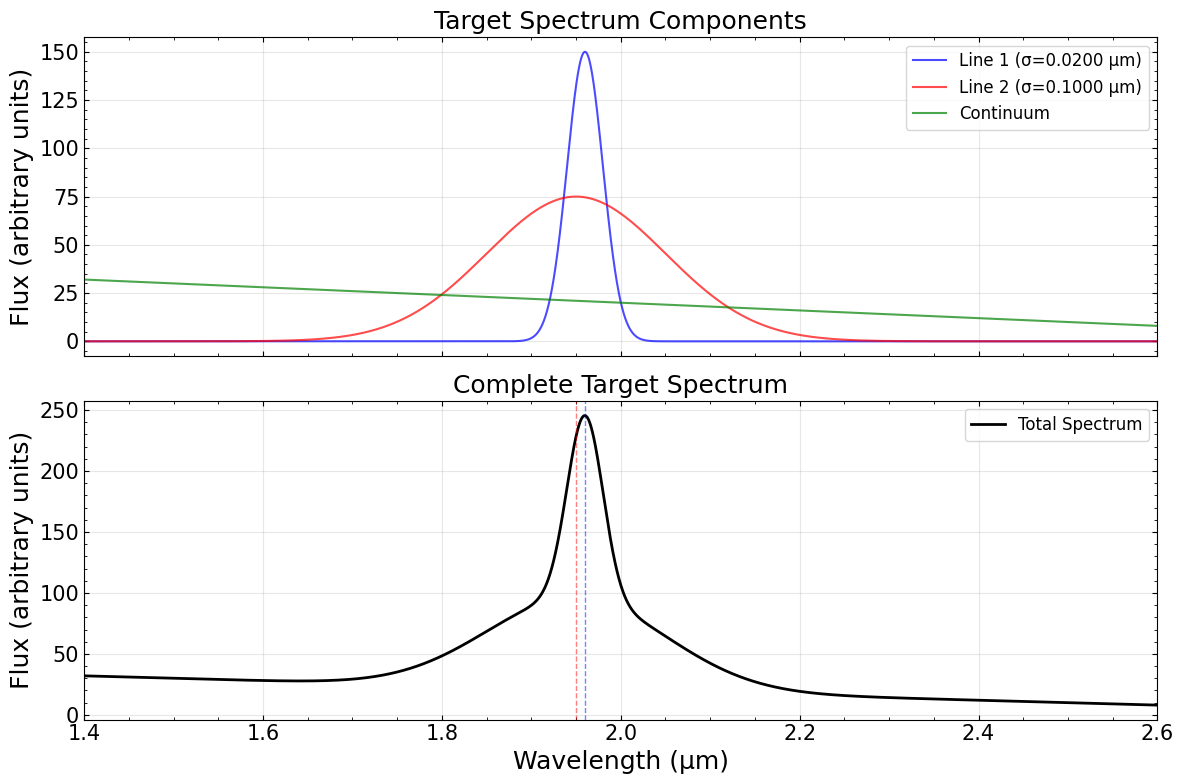


=== Target Spectrum Statistics ===
Total flux range: 8.0 - 245.4
Line 1 peak SNR (relative to continuum): 7.5
Line 2 peak SNR (relative to continuum): 3.8
Line 1 FWHM: 0.0471 μm
Line 2 FWHM: 0.2355 μm


In [4]:
# Visualize the target spectrum and its components
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Top plot: Individual components
axes[0].plot(wavelength, line1_component, "b-", alpha=0.7, linewidth=1.5, label=f"Line 1 (σ={line1_width:.4f} μm)")
axes[0].plot(wavelength, line2_component, "r-", alpha=0.7, linewidth=1.5, label=f"Line 2 (σ={line2_width:.4f} μm)")
axes[0].plot(wavelength, continuum_component, "g-", alpha=0.7, linewidth=1.5, label="Continuum")
axes[0].set_ylabel("Flux (arbitrary units)")
axes[0].set_title("Target Spectrum Components")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(wavelength_min, wavelength_max)

# Bottom plot: Complete spectrum
axes[1].plot(wavelength, true_spectrum, "k-", linewidth=2, label="Total Spectrum")
axes[1].axvline(line1_center, color="blue", linestyle="--", alpha=0.5, linewidth=1)
axes[1].axvline(line2_center, color="red", linestyle="--", alpha=0.5, linewidth=1)
axes[1].set_xlabel("Wavelength (μm)")
axes[1].set_ylabel("Flux (arbitrary units)")
axes[1].set_title("Complete Target Spectrum")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(wavelength_min, wavelength_max)

plt.tight_layout()
# plt.savefig("01_target_spectrum.png", dpi=150, bbox_inches="tight")
plt.show()

# Print some statistics
print("\n=== Target Spectrum Statistics ===")
print(f"Total flux range: {np.min(true_spectrum):.1f} - {np.max(true_spectrum):.1f}")
print(f"Line 1 peak SNR (relative to continuum): {line1_amplitude / continuum_amplitude:.1f}")
print(f"Line 2 peak SNR (relative to continuum): {line2_amplitude / continuum_amplitude:.1f}")
print(f"Line 1 FWHM: {2.355 * line1_width:.4f} μm")
print(f"Line 2 FWHM: {2.355 * line2_width:.4f} μm")

## 2. Observation Simulation

In this section, we simulate realistic SPHEREx observations:
- Narrow-band filter observations with configurable bandwidth
- Realistic noise modeling (photon noise + read noise)
- Random observation distribution across the wavelength range

**Note**: The noise model has been improved compared to the original test code.

In [5]:
# === Observation Simulation Parameters ===
# Users can modify these to test different observation scenarios

# Number of observations
n_observations = 800

# Filter bandwidth (microns) - this is the key undersampling parameter
# Larger bandwidth = more undersampling
filter_bandwidth = 10 * sigma  # microns

# Detector/instrument parameters
gain = 30.0  # Electrons per ADU (analog-to-digital unit)
read_noise = 70.0  # Read noise (electrons)
sky_background = 300.0  # Sky background flux (arbitrary units)
dark_current = 0.5  # Dark current (electrons/second)
exposure_time = 1.0  # Exposure time (seconds)

# Additional systematic noise (fraction of signal)
systematic_noise_fraction = 0.1  # 10% systematic noise

print("=== Observation Simulation Parameters ===")
print(f"Number of observations: {n_observations}")
print(f"Filter bandwidth: {filter_bandwidth:.3f} μm")

# Calculate undersampling factor
min_line_width = min(line1_width, line2_width)
undersampling_factor = filter_bandwidth / min_line_width
print(f"Undersampling factor: {undersampling_factor:.1f} (bandwidth/line_width)")
print(
    f"coverage factor (N_obs * bandwidth / total_width) = {n_observations * filter_bandwidth / (wavelength_max - wavelength_min):.1f}"
)

print(f"\nInstrument parameters:")
print(f"  Gain: {gain} e-/ADU")
print(f"  Read noise: {read_noise} e-")
print(f"  Sky background: {sky_background} units")
print(f"  Systematic noise: {systematic_noise_fraction * 100:.0f}% of signal")

=== Observation Simulation Parameters ===
Number of observations: 800
Filter bandwidth: 0.200 μm
Undersampling factor: 10.0 (bandwidth/line_width)
coverage factor (N_obs * bandwidth / total_width) = 133.3

Instrument parameters:
  Gain: 30.0 e-/ADU
  Read noise: 70.0 e-
  Sky background: 300.0 units
  Systematic noise: 10% of signal


In [6]:
# Generate observation centers (randomly distributed with some constraints)
# Ensure we don't place observations too close to the edges
margin = filter_bandwidth / 2
obs_centers = np.random.uniform(wavelength_min + margin, wavelength_max - margin, n_observations)

# Sort observations for better visualization
obs_centers = np.sort(obs_centers)

print(f"Generated {len(obs_centers)} observation centers")
print(f"Observation wavelength range: {obs_centers[0]:.3f} - {obs_centers[-1]:.3f} μm")

Generated 800 observation centers
Observation wavelength range: 1.500 - 2.499 μm


In [7]:
# Simulate observations with proper noise model
obs_fluxes = []
obs_uncertainties = []
obs_bandwidths = []

print("Simulating observations...")

for i, center in enumerate(obs_centers):
    # Define the wavelength range for this observation (boxcar filter)
    band_edges = (center - filter_bandwidth / 2, center + filter_bandwidth / 2)

    # Find wavelengths within this band
    mask = (wavelength >= band_edges[0]) & (wavelength <= band_edges[1])

    if np.sum(mask) > 0:
        # Calculate the true average flux within the band (boxcar integration)
        true_avg_flux = np.mean(true_spectrum[mask])

        # Add sky background and continuum contributions
        total_signal_electrons = (true_avg_flux + sky_background) * gain * exposure_time

        # Calculate noise contributions
        # Photon noise (shot noise): sqrt(N_photons)
        photon_noise = np.sqrt(abs(total_signal_electrons))

        # Read noise contribution
        read_noise_electrons = read_noise

        # Dark current noise
        dark_noise_electrons = np.sqrt(dark_current * exposure_time * np.sum(mask))

        # Total noise in electrons (quadrature sum)
        total_noise_electrons = np.sqrt(photon_noise**2 + read_noise_electrons**2 + dark_noise_electrons**2)

        # Convert noise back to flux units
        total_noise_flux = total_noise_electrons / (gain * exposure_time)

        # Add systematic noise (fraction of signal)
        systematic_noise = systematic_noise_fraction * true_avg_flux
        total_noise_flux = np.sqrt(total_noise_flux**2 + systematic_noise**2)

        # Generate observed flux with noise
        observed_flux = true_avg_flux + np.random.normal(0, total_noise_flux)

        # Store results
        obs_fluxes.append(observed_flux)
        obs_uncertainties.append(total_noise_flux)
        obs_bandwidths.append(filter_bandwidth)

# Convert to arrays
obs_fluxes = np.array(obs_fluxes)
obs_uncertainties = np.array(obs_uncertainties)
obs_bandwidths = np.array(obs_bandwidths)

print(f"Successfully simulated {len(obs_fluxes)} observations")

# Calculate and display observation statistics
peak_snr = np.max(obs_fluxes / obs_uncertainties)
median_snr = np.median(obs_fluxes / obs_uncertainties)
min_snr = np.min(obs_fluxes / obs_uncertainties)

print(f"\n=== Observation Statistics ===")
print(f"Flux range: {np.min(obs_fluxes):.1f} - {np.max(obs_fluxes):.1f}")
print(f"Uncertainty range: {np.min(obs_uncertainties):.2f} - {np.max(obs_uncertainties):.2f}")
print(f"Signal-to-Noise Ratio (SNR):")
print(f"  Peak SNR: {peak_snr:.1f}")
print(f"  Median SNR: {median_snr:.1f}")
print(f"  Minimum SNR: {min_snr:.1f}")

Simulating observations...
Successfully simulated 800 observations

=== Observation Statistics ===
Flux range: -0.1 - 151.1
Uncertainty range: 4.21 - 13.09
Signal-to-Noise Ratio (SNR):
  Peak SNR: 11.8
  Median SNR: 6.1
  Minimum SNR: -0.0


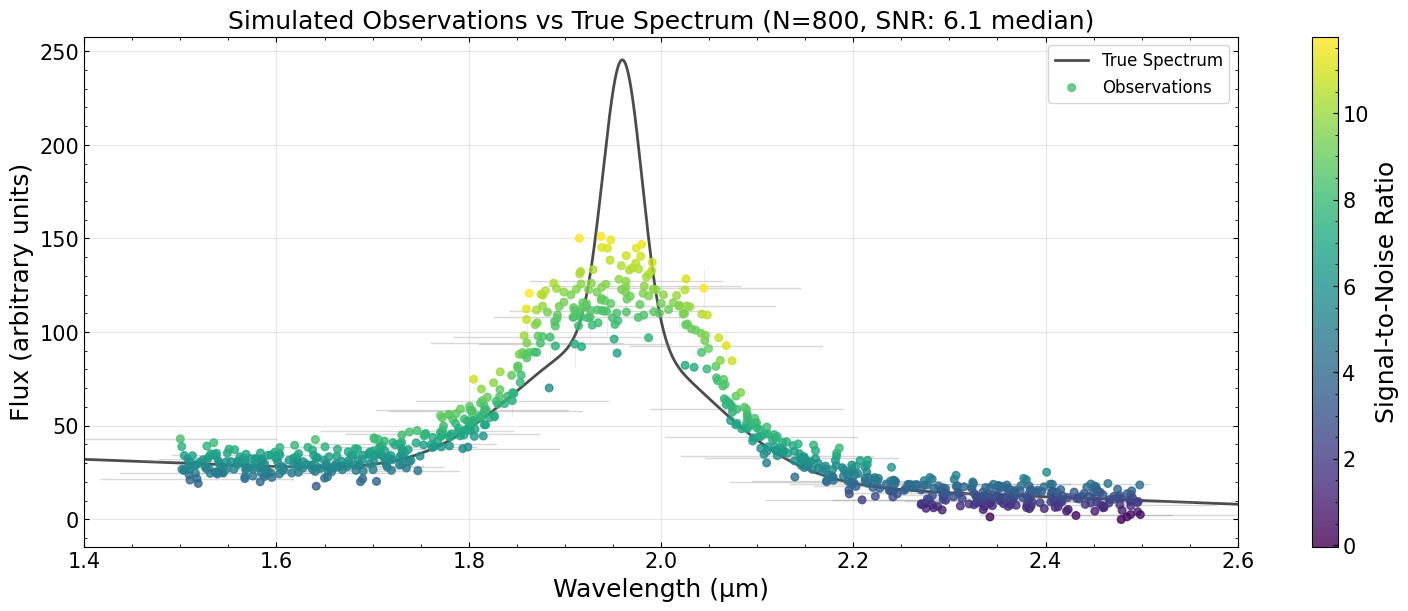


=== Observation Summary ===
Total observations: 800
Median SNR: 6.1
SNR range: -0.0 - 11.8
Error bars show: horizontal = bandwidth (0.200 μm), vertical = flux uncertainty


In [8]:
# Visualize the simulated observations
fig, ax = plt.subplots(figsize=(14, 6))

# Plot true spectrum
ax.plot(wavelength, true_spectrum, "k-", linewidth=2, alpha=0.7, label="True Spectrum")

# Calculate SNR for color coding
snr_values = obs_fluxes / obs_uncertainties

# Scatter plot with SNR color coding
scatter = ax.scatter(
    obs_centers, obs_fluxes, c=snr_values, s=30, cmap="viridis", alpha=0.8, label="Observations", zorder=5
)

# Add error bars for a subset of observations to show bandwidth
n_show = min(50, len(obs_centers))
show_indices = np.linspace(0, len(obs_centers) - 1, n_show, dtype=int)
for idx in show_indices:
    center = obs_centers[idx]
    flux = obs_fluxes[idx]
    bandwidth = obs_bandwidths[idx]
    uncertainty = obs_uncertainties[idx]

    # Horizontal error bar showing bandwidth (thin line)
    ax.plot([center - bandwidth / 2, center + bandwidth / 2], [flux, flux], "gray", alpha=0.3, linewidth=1)
    # Vertical error bar showing flux uncertainty
    ax.errorbar(center, flux, yerr=uncertainty, fmt="none", ecolor="gray", alpha=0.2, linewidth=0.5)

ax.set_xlabel("Wavelength (μm)")
ax.set_ylabel("Flux (arbitrary units)")
ax.set_title(f"Simulated Observations vs True Spectrum (N={n_observations}, SNR: {np.median(snr_values):.1f} median)")
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_xlim(wavelength_min, wavelength_max)

# Add colorbar for SNR
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Signal-to-Noise Ratio")

plt.show()

print(f"\n=== Observation Summary ===")
print(f"Total observations: {len(obs_centers)}")
print(f"Median SNR: {np.median(snr_values):.1f}")
print(f"SNR range: {np.min(snr_values):.1f} - {np.max(snr_values):.1f}")
print(f"Error bars show: horizontal = bandwidth ({filter_bandwidth:.3f} μm), vertical = flux uncertainty")

## 3. Spectral Reconstruction

In this section, we apply the Deep Image Prior reconstruction:
- Configure the SED reconstruction parameters
- Run the PyTorch-based DIP solver
- Monitor the reconstruction process

The reconstruction uses a deep neural network with Continuous Wavelet Transform regularization.

In [9]:
# === SED Reconstruction Configuration ===
# Users can modify these parameters to optimize reconstruction

# Reconstruction resolution
reconstruction_resolution = 500  # Number of wavelength bins in reconstructed spectrum

# Deep Image Prior parameters
epochs = 5000  # Training iterations
learning_rate = 0.001  # Initial learning rate
regularization_weight = 0.001  # CWT regularization strength

# Learning rate scheduling
lr_scheduler_type = "cosine_warmup"  # Options: "none", "cosine", "cosine_warmup"
lr_warmup_epochs = 250  # Warmup epochs
lr_min_factor = 0.05  # Minimum LR fraction

# DIP network architecture
dip_filters = 32  # Number of filters in U-Net
dip_depth = 3  # U-Net depth
dip_noise_std = 0.1  # Input noise standard deviation

# jitter for DIP input
dip_jitter_ratio = 0.3  # fitter to the DIP input noise as a faction to the noise std
dip_jitter_ratio_min = None  # If not None, the jitter ratio will decay linearly to this minimum value over training

# CWT regularization scales (in pixel units)
cwt_scales = [1.0, 2.0, 3.0]  # Wavelet scales for regularization

print("=== SED Reconstruction Configuration ===")
print(f"Reconstruction resolution: {reconstruction_resolution} wavelength bins")
print(f"Training epochs: {epochs}")
print(f"Learning rate: {learning_rate}")
print(f"Learning rate scheduler: {lr_scheduler_type}")
print(f"Regularization weight: {regularization_weight}")
print(f"CWT scales: {cwt_scales}")
print(f"DIP architecture: {dip_filters} filters, depth {dip_depth}")

=== SED Reconstruction Configuration ===
Reconstruction resolution: 500 wavelength bins
Training epochs: 5000
Learning rate: 0.001
Learning rate scheduler: cosine_warmup
Regularization weight: 0.001
CWT scales: [1.0, 2.0, 3.0]
DIP architecture: 32 filters, depth 3


In [10]:
# Create the SED configuration
config = SEDConfig(
    wavelength_range=(wavelength_min, wavelength_max),
    global_resolution=reconstruction_resolution,
    device=device,
    epochs=epochs,
    learning_rate=learning_rate,
    learning_rate_scheduler_type=lr_scheduler_type,
    learning_rate_warmup_epochs=lr_warmup_epochs,
    learning_rate_min_factor=lr_min_factor,
    regularization_weight=regularization_weight,
    cwt_scales=cwt_scales,
    dip_filters=dip_filters,
    dip_depth=dip_depth,
    dip_noise_std=dip_noise_std,
    dip_noise_jitter_initial_ratio=dip_jitter_ratio,
    dip_noise_jitter_min_ratio=dip_jitter_ratio_min,
    sigma_threshold=3.0,  # Quality filtering
    enable_sigma_clip=True,  # Outlier removal
)

print("✓ SED configuration created successfully")
print(f"Using device: {config.device}")
print(f"Wavelength range: {config.wavelength_range[0]:.2f} - {config.wavelength_range[1]:.2f} μm")
print(f"Global resolution: {config.global_resolution}")

✓ SED configuration created successfully
Using device: mps
Wavelength range: 1.40 - 2.60 μm
Global resolution: 500


In [11]:
# Prepare data for reconstruction

# 1. Create BandData object
band_data = BandData(
    band="Sim",  # Simulation band name
    flux=obs_fluxes,
    flux_error=obs_uncertainties,
    wavelength_center=obs_centers,
    bandwidth=obs_bandwidths,
)

# 2. Create band data dictionary
band_data_dict = {"Sim": band_data}

print("✓ BandData object created")
print(f"Band: {band_data.band}")
print(f"Number of observations: {len(band_data.flux)}")
print(f"Flux range: {np.min(band_data.flux):.1f} - {np.max(band_data.flux):.1f}")
print(f"Uncertainty range: {np.min(band_data.flux_error):.2f} - {np.max(band_data.flux_error):.2f}")

✓ BandData object created
Band: Sim
Number of observations: 800
Flux range: -0.1 - 151.1
Uncertainty range: 4.21 - 13.09


In [12]:
# 3. Build the global observation data matrix
print("Building global observation data...")
dataset = build_global_observation_data(band_data_dict, config)

print("✓ Global observation data built successfully")
print(f"Global wavelength grid: {len(dataset.global_wavelength_grid)} points")
print(f"Global wavelength range: {dataset.global_wavelength_grid[0]:.3f} - {dataset.global_wavelength_grid[-1]:.3f} μm")
print(f"Observation matrix shape: {dataset.H_shape}")
print(f"Number of observations: {len(dataset.observations)}")

Building global observation data...
✓ Global observation data built successfully
Global wavelength grid: 500 points
Global wavelength range: 1.400 - 2.600 μm
Observation matrix shape: (800, 500)
Number of observations: 800


In [13]:
# 4. Run the spectral reconstruction
print("Starting spectral reconstruction...")
print(f"This may take {epochs / 1000:.1f}-{epochs / 500:.1f} minutes depending on your hardware.")
print("Watch the progress bar below:")

# Run the reconstruction
reconstructed_tensor, solver_status, solver_time = solve_global_reconstruction(dataset, config)

# Convert to numpy arrays for analysis
reconstructed_spectrum = reconstructed_tensor.numpy()
reconstructed_wavelength = dataset.global_wavelength_grid.numpy()

print(f"\n✓ Reconstruction completed!")
print(f"Solver status: {solver_status}")
print(f"Total time: {solver_time:.2f} seconds ({solver_time / 60:.1f} minutes)")

Starting spectral reconstruction...
This may take 5.0-10.0 minutes depending on your hardware.
Watch the progress bar below:


Optimizing Spectrum: 100%|██████████| 5000/5000 [00:33<00:00, 148.30it/s, Loss=1.0462e+01, Data=1.0328e+01, Reg=1.3378e-01, LR=5.10e-05]


✓ Reconstruction completed!
Solver status: success
Total time: 33.73 seconds (0.6 minutes)


## 4. Quality Assessment

In this final section, we evaluate the reconstruction quality:
- Compare reconstructed vs true spectrum
- Calculate reconstruction metrics
- Analyze residuals and goodness of fit
- Visualize the complete reconstruction pipeline

In [14]:
# Interpolate true spectrum to reconstruction wavelength grid for comparison
from scipy.interpolate import interp1d

# Create interpolation function
f_true = interp1d(wavelength, true_spectrum, bounds_error=False, fill_value=0.0)

# Interpolate to reconstruction grid
true_on_recon_grid = f_true(reconstructed_wavelength)

# === Step 1: Observation vs Expected Consistency Check ===
# First, check if the reconstructed spectrum can explain the observations properly


def calculate_observation_consistency(
    obs_fluxes, obs_centers, obs_uncertainties, obs_bandwidths, reconstructed_spectrum, reconstructed_wavelength
):
    """
    Calculate consistency between observations and expected values from reconstructed spectrum.

    This is a direct comparison that tests whether the model properly explains the data.
    """

    expected_fluxes = []
    observation_residuals = []

    for i, center in enumerate(obs_centers):
        # Compute expected observation from reconstructed model
        band_mask = (reconstructed_wavelength >= center - obs_bandwidths[i] / 2) & (
            reconstructed_wavelength <= center + obs_bandwidths[i] / 2
        )
        if np.sum(band_mask) > 0:
            # Expected observation is the mean flux within the band
            expected_flux = np.mean(reconstructed_spectrum[band_mask])
            expected_fluxes.append(expected_flux)

            # Residual = observed - expected
            residual = obs_fluxes[i] - expected_flux
            observation_residuals.append(residual)

    expected_fluxes = np.array(expected_fluxes)
    observation_residuals = np.array(observation_residuals)

    # Normalized residuals (in units of uncertainty)
    normalized_residuals = observation_residuals / obs_uncertainties

    # Calculate consistency metrics
    chi2 = np.sum(normalized_residuals**2)
    chi2_nu = chi2 / len(normalized_residuals)  # Reduced chi-squared

    # Fraction of outliers (> 3σ and > 5σ)
    outliers_3sigma = np.sum(np.abs(normalized_residuals) > 3)
    outliers_5sigma = np.sum(np.abs(normalized_residuals) > 5)
    fraction_3sigma = outliers_3sigma / len(normalized_residuals)
    fraction_5sigma = outliers_5sigma / len(normalized_residuals)

    # Correlation between observed and expected
    correlation = np.corrcoef(obs_fluxes, expected_fluxes)[0, 1]
    if np.isnan(correlation):
        correlation = 0.0

    # RMS of normalized residuals
    rms_normalized = np.sqrt(np.mean(normalized_residuals**2))

    return {
        "expected_fluxes": expected_fluxes,
        "observation_residuals": observation_residuals,
        "normalized_residuals": normalized_residuals,
        "chi2": chi2,
        "chi2_nu": chi2_nu,
        "correlation_obs_exp": correlation,
        "rms_normalized": rms_normalized,
        "fraction_outliers_3sigma": fraction_3sigma,
        "fraction_outliers_5sigma": fraction_5sigma,
        "n_outliers_3sigma": outliers_3sigma,
        "n_outliers_5sigma": outliers_5sigma,
    }


# Run observation consistency check
obs_consistency = calculate_observation_consistency(
    obs_fluxes, obs_centers, obs_uncertainties, obs_bandwidths, reconstructed_spectrum, reconstructed_wavelength
)

print("=== Step 1: Observation Consistency Check ===")
print(f"Observed vs Expected Correlation: {obs_consistency['correlation_obs_exp']:.3f}")
print(f"Reduced χ²: {obs_consistency['chi2_nu']:.2f}")
print(f"RMS of normalized residuals: {obs_consistency['rms_normalized']:.2f}σ")
print(
    f"Outliers > 3σ: {obs_consistency['n_outliers_3sigma']}/{len(obs_consistency['normalized_residuals'])} ({obs_consistency['fraction_outliers_3sigma'] * 100:.1f}%)"
)
print(
    f"Outliers > 5σ: {obs_consistency['n_outliers_5sigma']}/{len(obs_consistency['normalized_residuals'])} ({obs_consistency['fraction_outliers_5sigma'] * 100:.1f}%)"
)

# Consistency assessment
if obs_consistency["chi2_nu"] < 2.0 and obs_consistency["fraction_outliers_3sigma"] < 0.1:
    print("✓ EXCELLENT: Model explains observations very well")
elif obs_consistency["chi2_nu"] < 3.0 and obs_consistency["fraction_outliers_3sigma"] < 0.2:
    print("✓ GOOD: Model explains observations adequately")
elif obs_consistency["chi2_nu"] < 5.0 and obs_consistency["fraction_outliers_3sigma"] < 0.3:
    print("⚠️  MODERATE: Some inconsistencies between model and observations")
else:
    print("❌ POOR: Model does not explain observations well")

print("\n" + "=" * 60)


# === Step 2: Spectral Similarity Metrics ===
# Now check similarity between true and reconstructed spectra


def calculate_reconstruction_metrics(true_flux, recon_flux):
    """Calculate various reconstruction quality metrics."""

    # Remove any NaN or infinite values
    mask = np.isfinite(true_flux) & np.isfinite(recon_flux)
    true_clean = true_flux[mask]
    recon_clean = recon_flux[mask]

    if len(true_clean) == 0:
        return {}

    # Root Mean Square Error (RMSE)
    rmse = np.sqrt(np.mean((true_clean - recon_clean) ** 2))

    # Normalized RMSE (relative to true flux range)
    flux_range = np.max(true_clean) - np.min(true_clean)
    nrmse = rmse / flux_range if flux_range > 0 else np.inf

    # Pearson correlation coefficient
    correlation = np.corrcoef(true_clean, recon_clean)[0, 1]
    if np.isnan(correlation):
        correlation = 0.0

    # Peak amplitude recovery
    true_peak_idx = np.argmax(true_clean)
    recon_peak_idx = np.argmax(recon_clean)
    true_peak_flux = np.max(true_clean)
    recon_peak_flux = np.max(recon_clean)
    peak_recovery = recon_peak_flux / true_peak_flux if true_peak_flux > 0 else 0.0

    # Line center recovery (if lines are present)
    from scipy.signal import find_peaks

    true_peaks, _ = find_peaks(true_clean, height=np.max(true_clean) * 0.1)
    recon_peaks, _ = find_peaks(recon_clean, height=np.max(recon_clean) * 0.1)

    return {
        "rmse": rmse,
        "nrmse": nrmse,
        "correlation": correlation,
        "true_peak_flux": true_peak_flux,
        "recon_peak_flux": recon_peak_flux,
        "peak_recovery": peak_recovery,
        "true_peak_idx": true_peak_idx,
        "recon_peak_idx": recon_peak_idx,
        "true_peaks_count": len(true_peaks),
        "recon_peaks_count": len(recon_peaks),
    }


# Calculate metrics
metrics = calculate_reconstruction_metrics(true_on_recon_grid, reconstructed_spectrum)

print("=== Step 2: Spectral Similarity Assessment ===")
print(f"Root Mean Square Error (RMSE): {metrics['rmse']:.2f}")
print(f"Normalized RMSE: {metrics['nrmse']:.3f} ({metrics['nrmse'] * 100:.1f}% of flux range)")
print(f"Pearson Correlation: {metrics['correlation']:.3f}")
print(f"Peak Flux Recovery: {metrics['peak_recovery']:.2f} ({metrics['peak_recovery'] * 100:.1f}%)")
print(f"True peaks detected: {metrics['true_peaks_count']}")
print(f"Reconstructed peaks detected: {metrics['recon_peaks_count']}")

# Quality assessment
if metrics["correlation"] > 0.95 and metrics["nrmse"] < 0.1:
    print("\n✓ EXCELLENT reconstruction quality")
elif metrics["correlation"] > 0.9 and metrics["nrmse"] < 0.2:
    print("\n✓ GOOD reconstruction quality")
elif metrics["correlation"] > 0.8 and metrics["nrmse"] < 0.3:
    print("\n⚠️  MODERATE reconstruction quality")
else:
    print("\n❌ POOR reconstruction quality - consider adjusting parameters")

=== Step 1: Observation Consistency Check ===
Observed vs Expected Correlation: 0.979
Reduced χ²: 1.04
RMS of normalized residuals: 1.02σ
Outliers > 3σ: 2/800 (0.2%)
Outliers > 5σ: 0/800 (0.0%)
✓ EXCELLENT: Model explains observations very well

=== Step 2: Spectral Similarity Assessment ===
Root Mean Square Error (RMSE): 9.43
Normalized RMSE: 0.038 (3.8% of flux range)
Pearson Correlation: 0.979
Peak Flux Recovery: 0.94 (93.9%)
True peaks detected: 2
Reconstructed peaks detected: 5

✓ EXCELLENT reconstruction quality


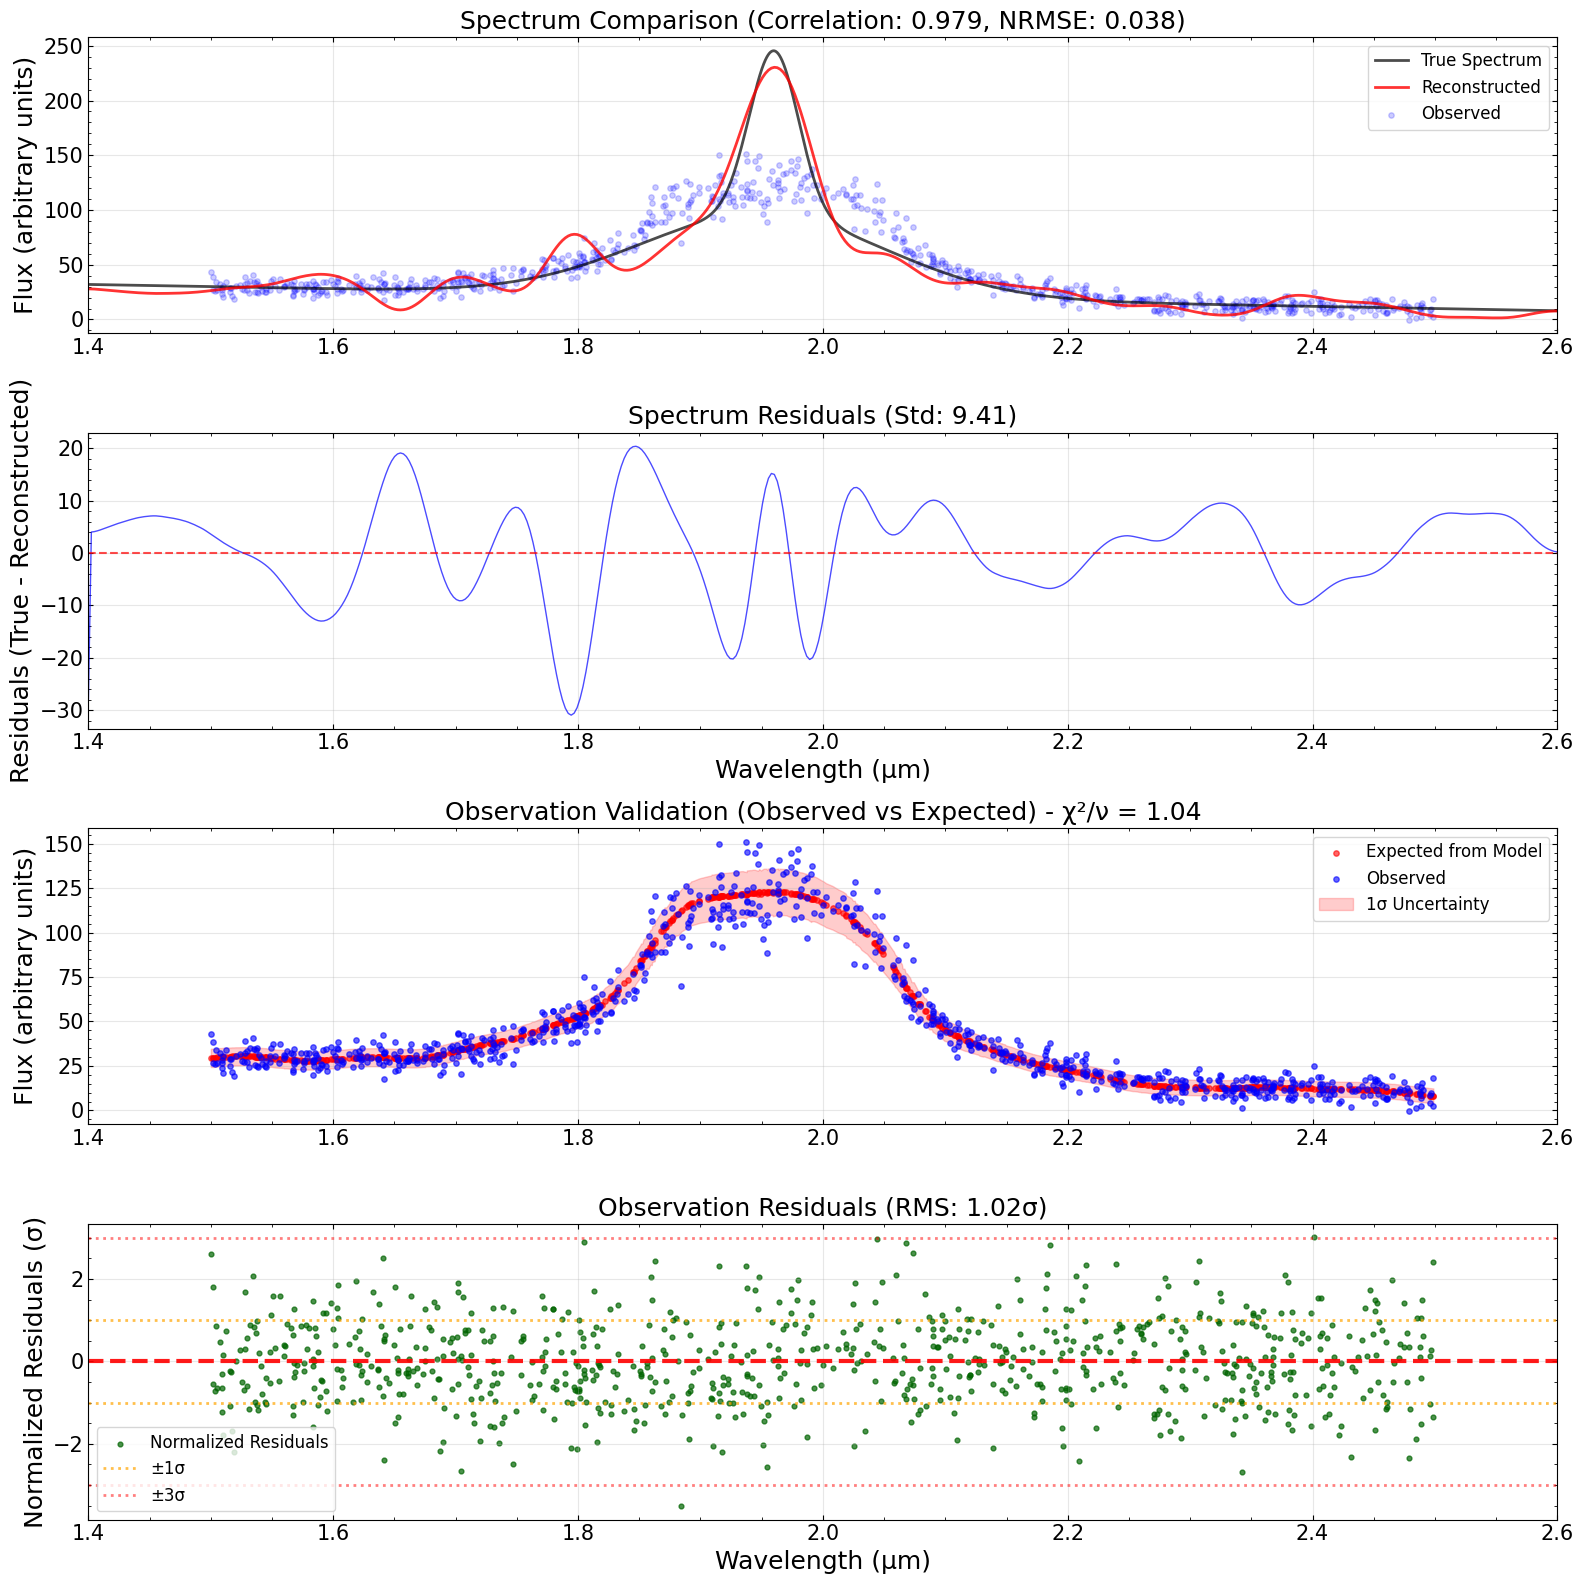


=== Comprehensive Quality Assessment ===

📊 Spectrum Similarity Metrics:
   Correlation: 0.979
   Normalized RMSE: 0.038 (3.8%)
   Peak recovery: 93.9%
   Spectrum residual std: 9.41

📡 Observation Consistency Metrics:
   Observed vs Expected Correlation: 0.979
   Reduced χ²: 1.04
   RMS of normalized residuals: 1.02σ
   Outliers > 1σ: 252/800 (31.5%)
   Outliers > 3σ: 2/800 (0.2%)
   Outliers > 5σ: 0/800 (0.0%)

🎯 Overall Assessment:
   ✅ EXCELLENT: Both observation consistency and spectral similarity are outstanding


In [15]:
# Create comprehensive quality assessment plots
fig = plt.figure(figsize=(16, 16))

# Top-left: Spectrum comparison (true vs reconstructed)
ax1 = plt.subplot(4, 1, 1)
ax1.plot(wavelength, true_spectrum, "k-", linewidth=2, alpha=0.7, label="True Spectrum")
ax1.plot(reconstructed_wavelength, reconstructed_spectrum, "r-", linewidth=2, alpha=0.8, label="Reconstructed")
ax1.scatter(obs_centers, obs_fluxes, c="blue", s=15, alpha=0.2, label="Observed", zorder=1)
ax1.set_ylabel("Flux (arbitrary units)")
ax1.set_title(f"Spectrum Comparison (Correlation: {metrics['correlation']:.3f}, NRMSE: {metrics['nrmse']:.3f})")
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xlim(wavelength_min, wavelength_max)

# Bottom-left: Spectrum residuals
ax2 = plt.subplot(4, 1, 2)
residuals = true_on_recon_grid - reconstructed_spectrum
ax2.plot(reconstructed_wavelength, residuals, "b-", linewidth=1, alpha=0.7)
ax2.axhline(0, color="red", linestyle="--", alpha=0.7)
ax2.set_xlabel("Wavelength (μm)")
ax2.set_ylabel("Residuals (True - Reconstructed)")
ax2.set_title(f"Spectrum Residuals (Std: {np.std(residuals):.2f})")
ax2.grid(True, alpha=0.3)
ax2.set_xlim(wavelength_min, wavelength_max)

# Top-right: Observation vs Expected comparison
ax3 = plt.subplot(4, 1, 3)

# Plot observed vs expected fluxes
ax3.scatter(
    obs_centers, obs_consistency["expected_fluxes"], c="red", s=15, alpha=0.6, label="Expected from Model", zorder=3
)
ax3.scatter(obs_centers, obs_fluxes, c="blue", s=15, alpha=0.6, label="Observed", zorder=4)

# Add 1-sigma error bands
x_sorted = obs_centers
y_lower = obs_consistency["expected_fluxes"] - obs_uncertainties
y_upper = obs_consistency["expected_fluxes"] + obs_uncertainties

# Create 1-sigma shading
ax3.fill_between(x_sorted, y_lower, y_upper, alpha=0.2, color="red", label="1σ Uncertainty")
ax3.set_ylabel("Flux (arbitrary units)")
ax3.set_title(f"Observation Validation (Observed vs Expected) - χ²/ν = {obs_consistency['chi2_nu']:.2f}")
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_xlim(wavelength_min, wavelength_max)

# Bottom-right: Observation residuals
ax4 = plt.subplot(4, 1, 4)

# Calculate observation residuals
obs_residuals = obs_fluxes - obs_consistency["expected_fluxes"]
normalized_residuals = obs_consistency["normalized_residuals"]

ax4.scatter(obs_centers, normalized_residuals, c="darkgreen", s=12, alpha=0.7, label="Normalized Residuals")
ax4.axhline(0, lw=3, color="red", linestyle="--", alpha=0.9)
ax4.axhline(1, lw=2, color="orange", linestyle=":", alpha=0.7, label="±1σ")
ax4.axhline(-1, lw=2, color="orange", linestyle=":", alpha=0.7)
ax4.axhline(3, lw=2, color="red", linestyle=":", alpha=0.5, label="±3σ")
ax4.axhline(-3, lw=2, color="red", linestyle=":", alpha=0.5)

ax4.set_xlabel("Wavelength (μm)")
ax4.set_ylabel("Normalized Residuals (σ)")
ax4.set_title(f"Observation Residuals (RMS: {obs_consistency['rms_normalized']:.2f}σ)")
ax4.legend()
ax4.grid(True, alpha=0.3)
ax4.set_xlim(wavelength_min, wavelength_max)

plt.tight_layout()
plt.show()

# Print comprehensive statistics
print(f"\n=== Comprehensive Quality Assessment ===")
print(f"\n📊 Spectrum Similarity Metrics:")
print(f"   Correlation: {metrics['correlation']:.3f}")
print(f"   Normalized RMSE: {metrics['nrmse']:.3f} ({metrics['nrmse'] * 100:.1f}%)")
print(f"   Peak recovery: {metrics['peak_recovery'] * 100:.1f}%")
print(f"   Spectrum residual std: {np.std(residuals):.2f}")

print(f"\n📡 Observation Consistency Metrics:")
print(f"   Observed vs Expected Correlation: {obs_consistency['correlation_obs_exp']:.3f}")
print(f"   Reduced χ²: {obs_consistency['chi2_nu']:.2f}")
print(f"   RMS of normalized residuals: {obs_consistency['rms_normalized']:.2f}σ")
print(
    f"   Outliers > 1σ: {np.sum(np.abs(obs_consistency['normalized_residuals']) > 1)}/{len(obs_consistency['normalized_residuals'])} ({100 * np.sum(np.abs(obs_consistency['normalized_residuals']) > 1) / len(obs_consistency['normalized_residuals']):.1f}%)"
)
print(
    f"   Outliers > 3σ: {obs_consistency['n_outliers_3sigma']}/{len(obs_consistency['normalized_residuals'])} ({obs_consistency['fraction_outliers_3sigma'] * 100:.1f}%)"
)
print(
    f"   Outliers > 5σ: {obs_consistency['n_outliers_5sigma']}/{len(obs_consistency['normalized_residuals'])} ({obs_consistency['fraction_outliers_5sigma'] * 100:.1f}%)"
)

print(f"\n🎯 Overall Assessment:")
# Combined quality assessment
if (
    obs_consistency["chi2_nu"] < 2.0
    and obs_consistency["fraction_outliers_3sigma"] < 0.1
    and metrics["correlation"] > 0.95
    and metrics["nrmse"] < 0.1
):
    print("   ✅ EXCELLENT: Both observation consistency and spectral similarity are outstanding")
elif (
    obs_consistency["chi2_nu"] < 3.0
    and obs_consistency["fraction_outliers_3sigma"] < 0.2
    and metrics["correlation"] > 0.9
    and metrics["nrmse"] < 0.2
):
    print("   ✅ GOOD: Both observation consistency and spectral similarity are acceptable")
elif (
    obs_consistency["chi2_nu"] < 5.0
    and obs_consistency["fraction_outliers_3sigma"] < 0.3
    and metrics["correlation"] > 0.8
    and metrics["nrmse"] < 0.3
):
    print("   ⚠️  MODERATE: Some inconsistencies but reconstruction is usable")
else:
    print("   ❌ POOR: Significant issues with either observation consistency or spectral similarity")